## <p style="text-align:center">Отчёт по практическому заданию по курсу<br>«<span style="color:MediumBlue">Численное моделирование в акустике</span>»<br>СПЕКТРАЛЬНЫЙ АНАЛИЗ РЕГУЛЯРНЫХ И СЛУЧАЙНЫХ СИГНАЛОВ<br><br><br>Работу выполнил: Ампилов П.С.<br>439 гр. РФ, 2022</p>
----

#### Для выполнения данной работы нам потребуются <span style="color:Green">библиотеки</span> для работы с <span style="color:Gold">массивами чисел</span> и <span style="color:Gold">построения графиков</span>:

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import jdc

# Константы
PI  =     np.pi
PI2 = 2 * np.pi

#### Задание выполнялось с использованием <span style="color:Gold">объектно-ориентированного программирования (ООП)</span>.
----

### *Программная реализация*

##### Для реализации спектрального анализа были написаны три класса: <span style="color:Green">Signal</span>, <span style="color:Green">Wave</span> и <span style="color:Green">Spectrum</span>. <br>Задача класса <span style="color:Green">Signal</span> — создание необходимых сигналов (объектов класса <span style="color:Green">Wave</span>), а также их суммирование. <br>Класс <span style="color:Green">Wave</span> модулирует (при необходимости) и реализует данный ему сигнал на заданном пользователем отрезке времени. <br>Наконец, класс <span style="color:Green">Spectrum</span> позволяет проводить прямое БПФ объектов класса <span style="color:Green">Wave</span>, а так же обратное БПФ объектов класса <span style="color:Green">Spectrum</span>. <br>Отрисовка графиков производится с помощью вспомогательной функции <span style="color:Gold">draw()</span>.
##### Наглядная схема работы программы:
<img src="program_work_example.png" title="Схема работы программы">

#### *Реализация класса <span style="color:Green">Signal</span>:*

##### Реализация волн <span style="color:MediumBlue">синуса</span> и <span style="color:MediumBlue">косинуса</span>:

In [15]:
class Signal():
    def __init__(self, discr_freq=44100):
        self.discr_freq = discr_freq
        
    def make_sine_wave(self, freq=40, duration=None, amp=1, init_phase=0):
        if duration == None:
            duration = 50
        
        duration *= 1e-3
        ts = np.linspace(0, duration, self.discr_freq)
        ys = amp * np.sin(PI2 * freq * ts + init_phase)
        
        return Wave(ts, ys, freq, duration, amp, discr_freq=self.discr_freq, 
                    init_phase=init_phase)
    
    def make_cosine_wave(self, freq=40, duration=None, amp=1, init_phase=0):
        if duration == None:
            duration = 50
        
        duration *= 1e-3
        ts = np.linspace(0, duration, self.discr_freq)
        ys = amp * np.cos(PI2 * freq * ts + init_phase)
        
        return Wave(ts, ys, freq, duration, amp, discr_freq=self.discr_freq, 
                    init_phase=init_phase)

##### Реализация <span style="color:MediumBlue">треугольного</span> импульса:

In [16]:
    %%add_to Signal
    def make_triangle_pulse(self, freq=40, duration=None, amp=1, init_phase=0):
        if duration == None:
            duration = 50
        
        duration *= 1e-3
        ts        = np.linspace(0, duration, self.discr_freq)
        cycles    = freq * ts + init_phase / PI2      
        frac, _   = np.modf(cycles)              
           
        # cycles — кол-во циклов треугольной последовательности.
        # frac   — дробная часть от длительности каждого цикла, 
        # изменяется от 0 до 1.
        
        # Значения   (frac - 0.5) изм-тся от -0.5 до 0.5, 
        # а их модуль от 0 до 0.5.
        # Построение (frac - 0.5) даст нам график последовательного 
        # пилообразного импульса, из которого можно получить 
        # треугольный, взяв модуль, сдвинув получившиеся значения вниз
        # на среднее ys.mean() и отнормировав их до необходимой амплитуды.
        
        ys  = np.abs(frac - 0.5)
        ys -= min(ys)                     # Сдвиг минимума к оси t
        ys  = amp * ys / abs(max(ys))     # Нормировка амплитуды

        return Wave(ts, ys, freq, duration, amp, discr_freq=self.discr_freq, 
                    init_phase=init_phase, is_pulse=True)

UsageError: Cell magic `%%add_to` not found.


##### Реализация <span style="color:MediumBlue">прямоугольного</span> импульса:

In [17]:
    %%add_to Signal
    def make_meander_pulse(self, freq=40, duration=None, amp=1, init_phase=0):
        if duration == None:
            duration = 50
        
        duration *= 1e-3
        ts  = np.linspace(0, duration, self.discr_freq)
        ys  = np.sign(np.sin(PI2 * freq * ts + init_phase))
        ys -= min(ys)                          # Сдвиг минимума к оси t
        ys  = amp * ys / abs(max(ys))          # Нормировка амплитуды
        
        return Wave(ts, ys, freq, duration, amp, discr_freq=self.discr_freq, 
                    init_phase=init_phase, is_pulse=True)

UsageError: Cell magic `%%add_to` not found.


##### Реализация <span style="color:MediumBlue">гауссового</span> импульса:

In [18]:
    %%add_to Signal
    def make_gaussian_pulse(self, freq=40, duration=None, amp=1, init_phase=0):
        if duration == None:
            duration = 50
        
        duration *= 1e-3
        ts = np.linspace(0, duration, self.discr_freq)
        half_period = 1 / (2*freq)
        
        # Требуется периодически продолжить гауссов импульс 
        # на всю временную ось. Формула для периодического 
        # продолжения функции phi(x), ограниченной [a,b]:
        # f(x) = phi(a + (x - a) % (b - a))
        # где f(x) — периодическое продолжение phi(x).
        # В нашем случае a = -half_period + init_phase, 
        # b = half_period + init_phase.
        
        def phi(t): 
            return amp * np.exp(-(t - init_phase)**2 / 
                                (2 * half_period*half_period))
        ys  = phi(-half_period + init_phase + (ts + half_period - init_phase) % 
                 (2 * half_period))
        ys -= min(ys)                    # Сдвиг минимума к оси t
        ys  = amp * ys / abs(max(ys))    # Нормировка амплитуды

        return Wave(ts, ys, freq, duration, amp, discr_freq=self.discr_freq, 
                    init_phase=init_phase, is_pulse=True)

UsageError: Cell magic `%%add_to` not found.


##### Реализация метода <span style="color:MediumBlue">суммирования</span> волн:

In [19]:
    %%add_to Signal
    def sum_waves(self, *waves):
        duration = waves[0].duration
        
        for wave in waves[1:]:
            if wave.duration != duration:
                print('ERROR: Сигналы должны быть одинаковой длительности!')
                return None
        
        freqs     = set()
        ys_sum    = 0
        mod_freqs = np.array([])
        
        modulation_found = False
        pulse_found      = False
        
        for wave in waves:
            ys_sum += np.array(wave.ys)
            freqs.add(wave.freq)
            
            if wave.is_modulated:
                modulation_found = True
                mod_freqs   = np.append(mod_freqs, wave.mod_freq)
            if wave.is_pulse:
                pulse_found = True

        amp      = np.max(ys_sum)
        freq     = min(freqs)
        max_freq = max(freqs)
        if not modulation_found:
            return Wave(waves[0].ts, ys_sum, freq, duration, amp, 
                        self.discr_freq, max_freq=max_freq)
        else:
            mod_freq = np.max(mod_freqs)
            return Wave(waves[0].ts, ys_sum, freq, duration, amp, 
                        self.discr_freq, is_pulse=pulse_found, 
                        mod_freq=mod_freq, is_modulated=modulation_found)

UsageError: Cell magic `%%add_to` not found.


#### *Реализация класса <span style="color:Green">Wave</span>:*

In [20]:
class Wave():
    def __init__(self, ts, ys, freq, duration, amp=1, discr_freq=44100, 
                 init_phase=0, is_pulse=False, is_modulated=False, 
                 max_freq=None, mod_freq=0, mod_deep=0):
        self.ts = ts
        self.ys = ys
        
        self.freq     = freq
        self.period   = 1 / freq
        self.duration = duration
        self.amp      = amp
        
        self.init_phase = init_phase
        self.discr_freq = discr_freq
        
        self.is_pulse     = is_pulse
        self.is_modulated = is_modulated
        
        self.mod_freq = mod_freq
        self.mod_deep = mod_deep
        
        if max_freq == None: self.max_freq = freq
        else:                self.max_freq = max_freq

##### Реализация методов <span style="color:MediumBlue">модуляции</span> волн и импульсов:

In [21]:
    %%add_to Wave
    def modulate_wave(self, mod_freq=2000, mod_deep=0.5):
        
        # S_am = Acos(PI2 * mod_freq * t)[1 + m cos(PI2 * freq * t + phi)], 
        # m - глубина модуляции, am - амплитудная модуляция, 
        # A - амплитуда несущей.
        # по опр. m = self.amp / A  =>  A = self.amp / m
        
        A   = self.amp / mod_deep
        ts  = self.ts
        ys  = A * (np.cos(PI2 * mod_freq * self.ts) * 
                   (1 + mod_deep * self.ys / self.amp))
        amp = A * (1 + mod_deep)
        
        return Wave(ts, ys, self.freq, self.duration, amp, self.discr_freq, 
                    self.init_phase, is_pulse=False, is_modulated=True, 
                    mod_freq=mod_freq, mod_deep=mod_deep)
    
    def modulate_pulse(self, mod_freq=1000):
        ts, ys = self.ts, self.ys * np.sin(PI2 * mod_freq * self.ts)
        
        return Wave(ts, ys, self.freq, self.duration, self.amp, self.discr_freq, 
                    self.init_phase, is_pulse=True, is_modulated=True, 
                    mod_freq=mod_freq)

UsageError: Cell magic `%%add_to` not found.


#### *Реализация класса <span style="color:Green">Spectrum</span>:*

In [22]:
class Spectrum():
    def __init__(self, amps=np.array([]), freqs=np.array([]), signal_amp=1,
                 signal_freq=None, window_length=0, sample_spacing=0):
        self.amps  = amps
        self.freqs = freqs
        self.signal_amp  = signal_amp
        self.signal_freq = signal_freq
        self.window_length  = window_length
        self.sample_spacing = sample_spacing

##### Реализация методов <span style="color:MediumBlue">прямого</span> и <span style="color:MediumBlue">обратного БПФ</span>:

In [23]:
    %%add_to Spectrum    
    def FFT(self, signal):
        window_length  = len(signal.ts)
        sample_spacing = signal.duration / window_length
        
        amps  = np.fft.fft(signal.ys)
        freqs = np.fft.fftfreq(n=window_length, d=sample_spacing)
        signal_amp  = signal.amp
        signal_freq = signal.freq
        
        return Spectrum(amps, freqs, signal_amp, signal_freq,
                        window_length, sample_spacing)
    
    def IFFT(self, spectrum):
        duration = spectrum.window_length * spectrum.sample_spacing
        amp  = spectrum.signal_amp
        freq = spectrum.signal_freq
        ts   = np.linspace(0, duration, spectrum.window_length)
        ys   = np.fft.ifft(spectrum.amps).real
        
        return Wave(ts, ys, freq=freq, duration=duration, amp=amp, 
                    discr_freq=spectrum.window_length)

UsageError: Cell magic `%%add_to` not found.


#### Реализация вспомогательной функции отрисовки графиков <span style="color:Gold">draw()</span>:

In [24]:
def draw(wave, spectrum, ifft_wave, title1='', title2='', title3=''):
    fig, ax = plt.subplots(1, 3)
    ax[0].set_title(title1, fontsize=18, color='red')
    ax[1].set_title(title2, fontsize=18, color='red')
    ax[2].set_title(title3, fontsize=18, color='red')
    
    ax[0].set_xlabel( 't, с',       fontsize=14)
    ax[1].set_xlabel(r'$\nu$, Гц',  fontsize=14)
    ax[2].set_xlabel( 't, с',       fontsize=14)
    
    ax[0].set_ylabel(r'$S\/(t)$',   fontsize=14)
    ax[1].set_ylabel(r'$G\/(\nu)$', fontsize=14)
    ax[2].set_ylabel(r'$S\/(t)$',   fontsize=14)
    
    fig.set_figwidth(20)
    fig.set_figheight(9)
    
    ax[0].plot(wave.ts, wave.ys)
    ax[1].plot(spectrum.freqs, np.abs(spectrum.amps))
    ax[2].plot(ifft_wave.ts, ifft_wave.ys)
    
    if wave.is_pulse:
        start1, end1 =  0,                 2  * wave.period
        start2, end2 = -50 * wave.freq,    50 * wave.freq
        start3, end3 =  start1,            end1
        
    elif not wave.is_modulated:
        start1, end1 =  0,                 2 * wave.period
        start2, end2 = -2 * wave.max_freq, 2 * wave.max_freq
        start3, end3 =  start1,            end1
        
    else:
        start1, end1 =  0,                 2 * wave.period
        start2, end2 = -2 * wave.mod_freq, 2 * wave.mod_freq
        start3, end3 =  start1,            end1
    
    ax[0].set_xlim(start1, end1)
    ax[1].set_xlim(start2, end2)
    ax[2].set_xlim(start3, end3)
    
    ax[0].grid()
    ax[1].grid()
    ax[2].grid()
    
    plt.show()

##### <span style="color:Crimson">Важно</span>: при отрисовке графиков во временной области отображаются только первые 2 периода волны, а при выводе спектра не отображаются нерелевантные околонулевые амплитуды на крайних частотах. 
----

### *Далее займёмся выполнением <span style="color:Green">поставленных задач</span>.* 


##### <span style="color:Gold">Единицы измерения</span>: длительность волн указывается в миллисекундах, амплитуды сигналов безразмерны, частоты - в герцах, начальные фазы - в радианах, глубина модуляции - так же безразмерный параметр.

In [25]:
signal   = Signal()
spectrum = Spectrum()

#### *<span style="color:Green">Гармонические сигналы</span>*

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для синуса

In [26]:
sin      = signal.make_sine_wave(freq=40, duration=1000)
sin_sp   = spectrum.FFT(sin)
sin_ifft = spectrum.IFFT(sin_sp)

draw(sin, sin_sp, sin_ifft, title1='sin', 
     title2='sin spectrum', title3='sin IFFT')

AttributeError: 'Spectrum' object has no attribute 'FFT'

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для косинуса

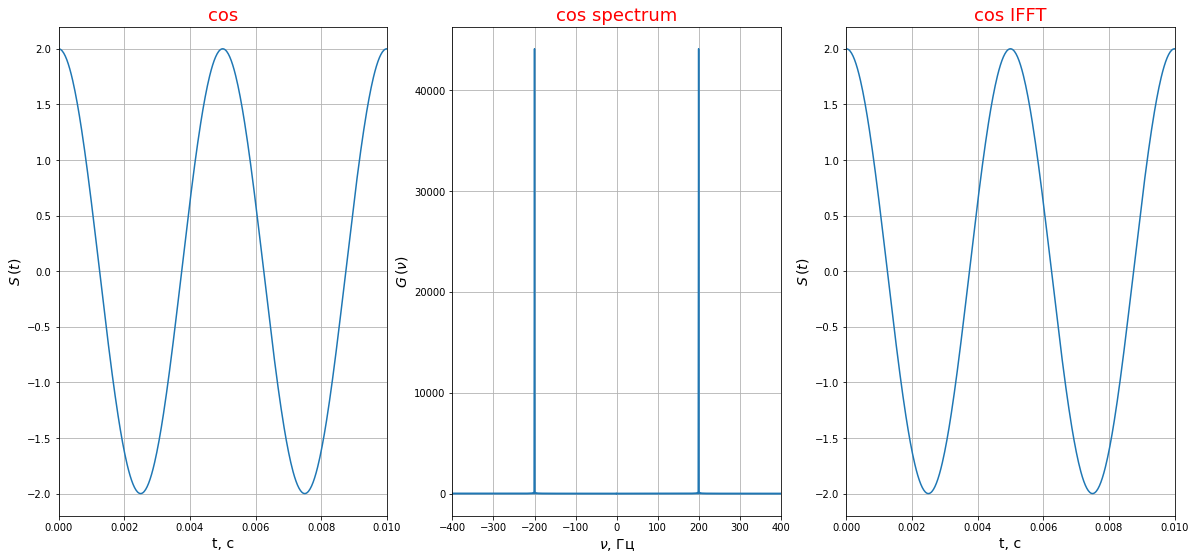

In [ ]:
cos      = signal.make_cosine_wave(freq=200, duration=1000, amp=2)
cos_sp   = spectrum.FFT(cos)
cos_ifft = spectrum.IFFT(cos_sp)

draw(cos, cos_sp, cos_ifft, title1='cos', 
     title2='cos spectrum', title3='cos IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для суммы гармонических колебаний

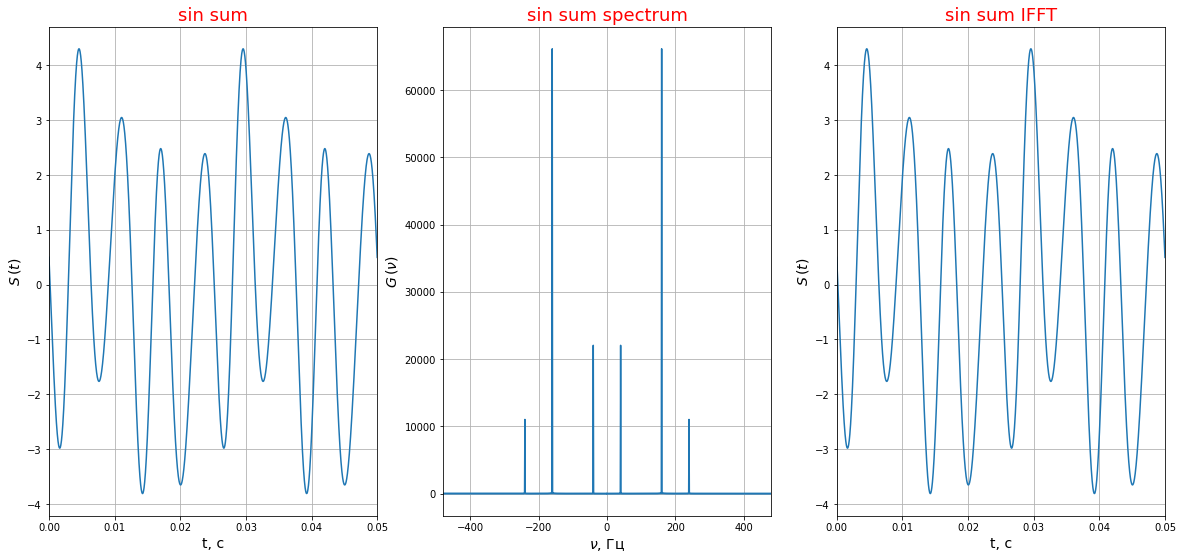

In [ ]:
sin1 = signal.make_sine_wave(freq=40,  duration=1000)
sin2 = signal.make_sine_wave(freq=160, duration=1000, amp=3,   init_phase=PI)
sin3 = signal.make_sine_wave(freq=240, duration=1000, amp=0.5, init_phase=PI/2)

sin_sum      = signal.sum_waves(sin1, sin2, sin3)
sin_sum_sp   = spectrum.FFT(sin_sum)
sin_sum_ifft = spectrum.IFFT(sin_sum_sp)

draw(sin_sum, sin_sum_sp, sin_sum_ifft, title1='sin sum', 
     title2='sin sum spectrum', title3='sin sum IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для суммы модулированных гармонических колебаний

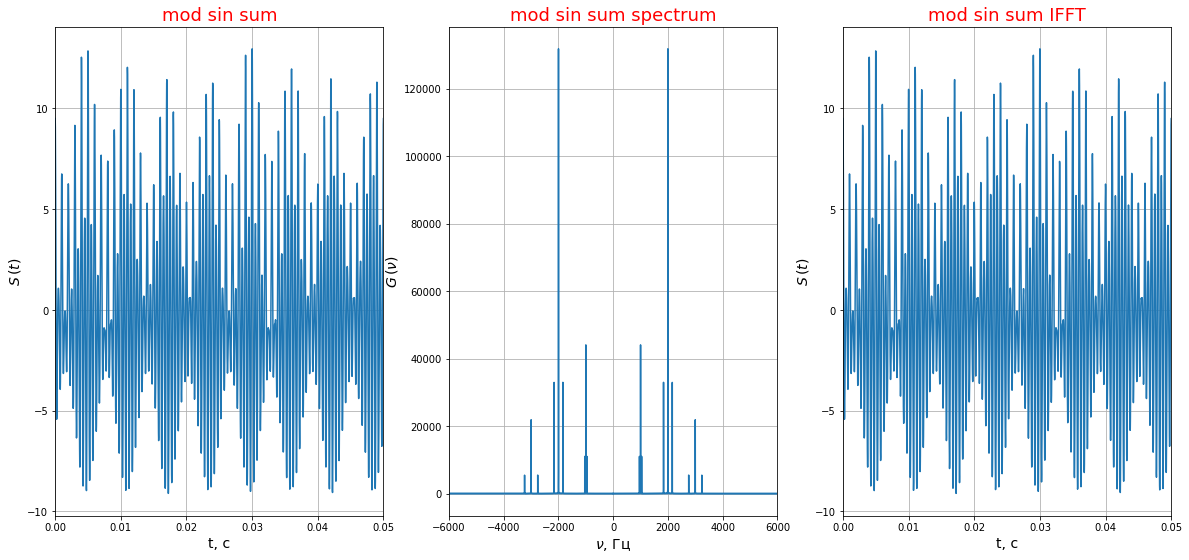

In [ ]:
sin1_mod = sin1.modulate_wave(mod_freq=1000, mod_deep=0.5)
sin2_mod = sin2.modulate_wave(mod_freq=2000, mod_deep=0.5)
sin3_mod = sin3.modulate_wave(mod_freq=3000, mod_deep=0.5)

mod_sin_sum      = signal.sum_waves(sin1_mod, sin2_mod, sin3_mod)
mod_sin_sum_sp   = spectrum.FFT(mod_sin_sum)
mod_sin_sum_ifft = spectrum.IFFT(mod_sin_sum_sp)

draw(mod_sin_sum, mod_sin_sum_sp, mod_sin_sum_ifft, title1='mod sin sum', 
     title2='mod sin sum spectrum', title3='mod sin sum IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для суммы сложных гармонических модулированных колебаний

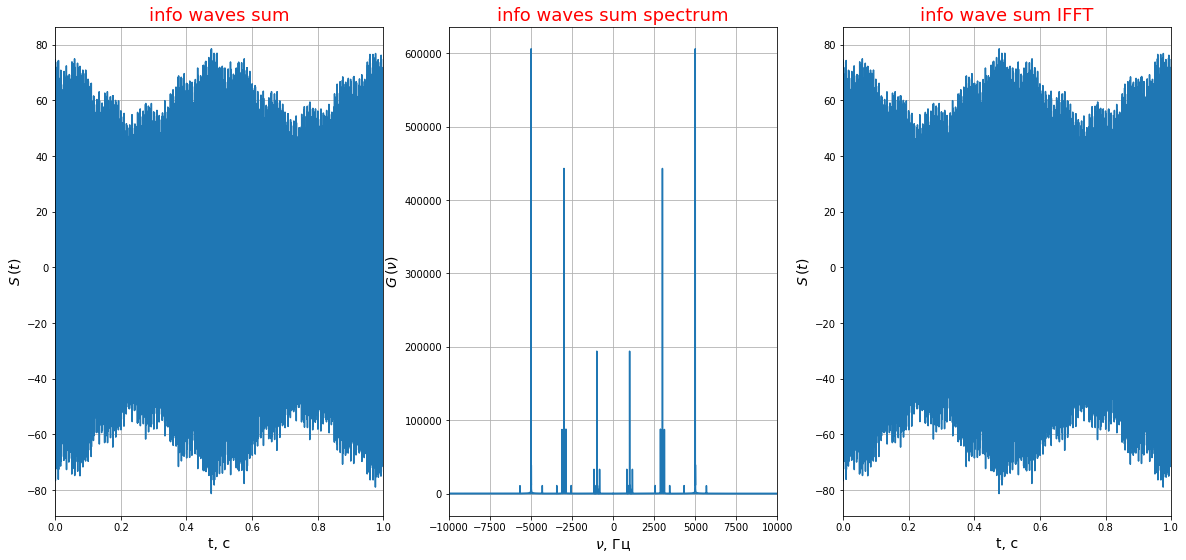

In [ ]:
# info wave #1
sin1 = signal.make_sine_wave(freq=40,  duration=1000)
sin2 = signal.make_sine_wave(freq=170, duration=1000, amp=3,   init_phase=PI)
sin3 = signal.make_sine_wave(freq=110, duration=1000, amp=0.5, init_phase=PI/2)
info_wave1 = signal.sum_waves(sin1, sin2, sin3)
info_wave1 = info_wave1.modulate_wave(mod_freq=1000, mod_deep=0.5)

# info wave #2
sin1 = signal.make_sine_wave(freq=440, duration=1000)
sin2 = signal.make_sine_wave(freq=120, duration=1000, amp=8,   init_phase=PI/4)
sin3 = signal.make_sine_wave(freq=50,  duration=1000, amp=1.5, init_phase=PI/3)
info_wave2 = signal.sum_waves(sin1, sin2, sin3)
info_wave2 = info_wave2.modulate_wave(mod_freq=3000, mod_deep=0.5)

# info wave #3
sin1 = signal.make_sine_wave(freq=680, duration=1000)
sin2 = signal.make_sine_wave(freq=10,  duration=1000, amp=3.5, init_phase=PI)
sin3 = signal.make_sine_wave(freq=2,   duration=1000, amp=10,  init_phase=PI/2)
info_wave3 = signal.sum_waves(sin1, sin2, sin3)
info_wave3 = info_wave3.modulate_wave(mod_freq=5000, mod_deep=0.5)

# info waves sum
info_waves_sum      = signal.sum_waves(info_wave1, info_wave2, info_wave3)
info_waves_sum_sp   = spectrum.FFT(info_waves_sum)
info_waves_sum_ifft = spectrum.IFFT(info_waves_sum_sp)

draw(info_waves_sum, info_waves_sum_sp, info_waves_sum_ifft, 
     title1='info waves sum', title2='info waves sum spectrum', 
     title3='info wave sum IFFT')

#### *<span style="color:Green">Одиночные импульсные сигналы</span>*

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для треугольного импульса

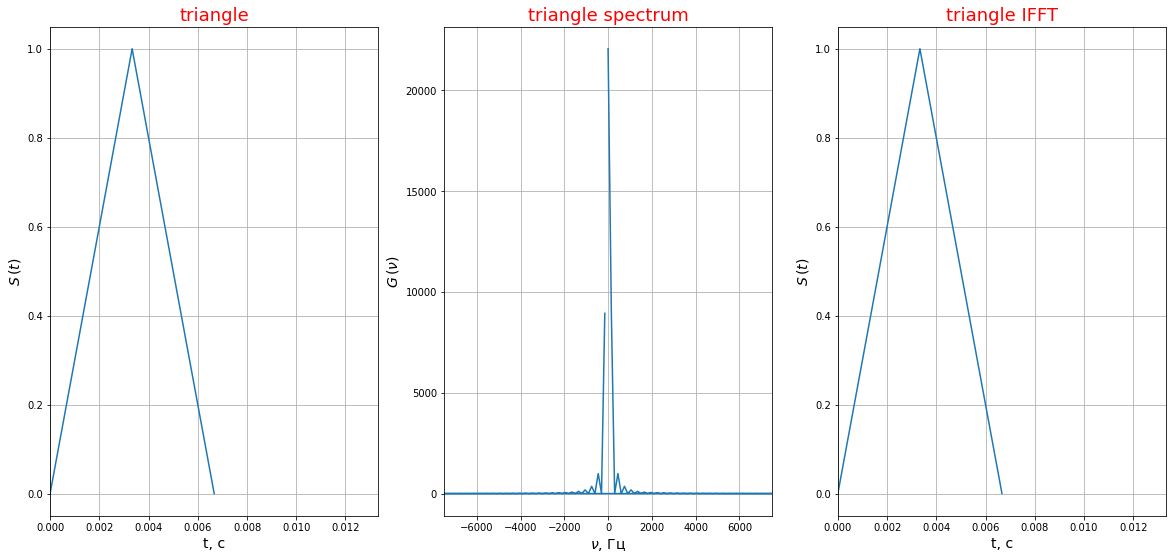

In [ ]:
triangle      = signal.make_triangle_pulse(freq=150, duration=1000/150, 
                                           amp=1, init_phase=PI)
triangle_sp   = spectrum.FFT(triangle)
triangle_ifft = spectrum.IFFT(triangle_sp)

draw(triangle, triangle_sp, triangle_ifft, title1='triangle', 
     title2='triangle spectrum', title3='triangle IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для прямоугольного импульса

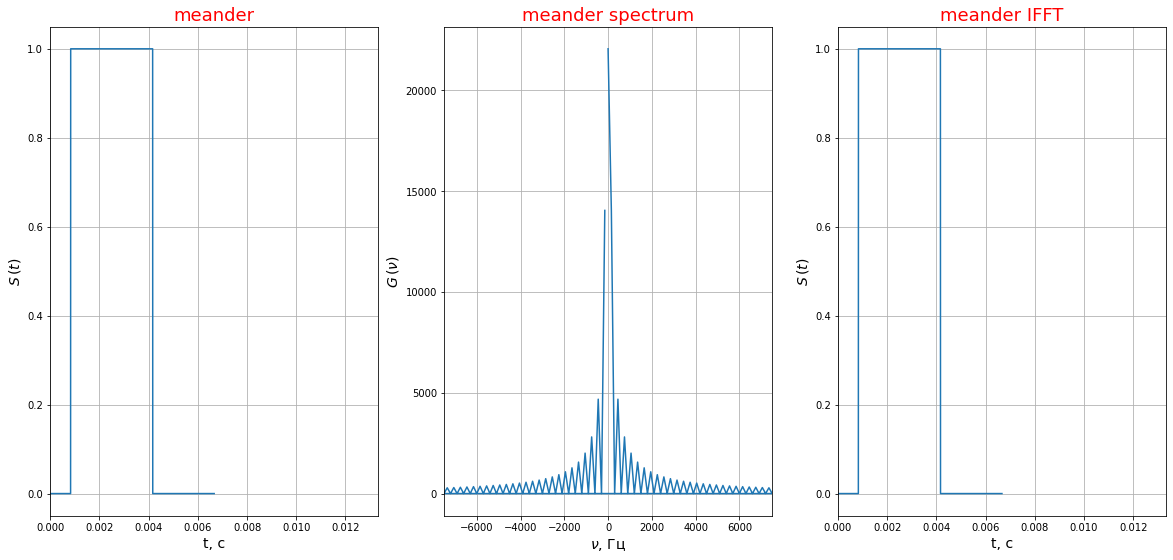

In [ ]:
meander      = signal.make_meander_pulse(freq=150, duration=1000/150, 
                                         amp=1, init_phase=-PI/4)
meander_sp   = spectrum.FFT(meander)
meander_ifft = spectrum.IFFT(meander_sp)

draw(meander, meander_sp, meander_ifft, title1='meander', 
     title2='meander spectrum', title3='meander IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для гауссова импульса

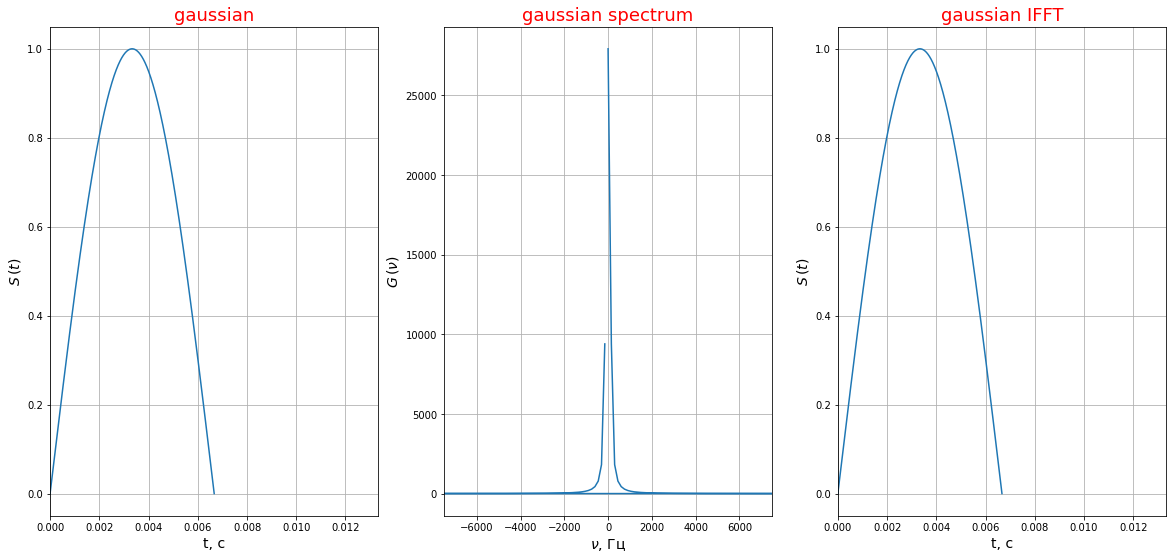

In [ ]:
gaussian      = signal.make_gaussian_pulse(freq=150, duration=1000/150, 
                                           amp=1, init_phase=1/150/2)
gaussian_sp   = spectrum.FFT(gaussian)
gaussian_ifft = spectrum.IFFT(gaussian_sp)

draw(gaussian, gaussian_sp, gaussian_ifft, title1='gaussian', 
     title2='gaussian spectrum', title3='gaussian IFFT')

#### *<span style="color:Green">Последовательность импульсных сигналов</span>*

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для треугольной последовательности импульсов

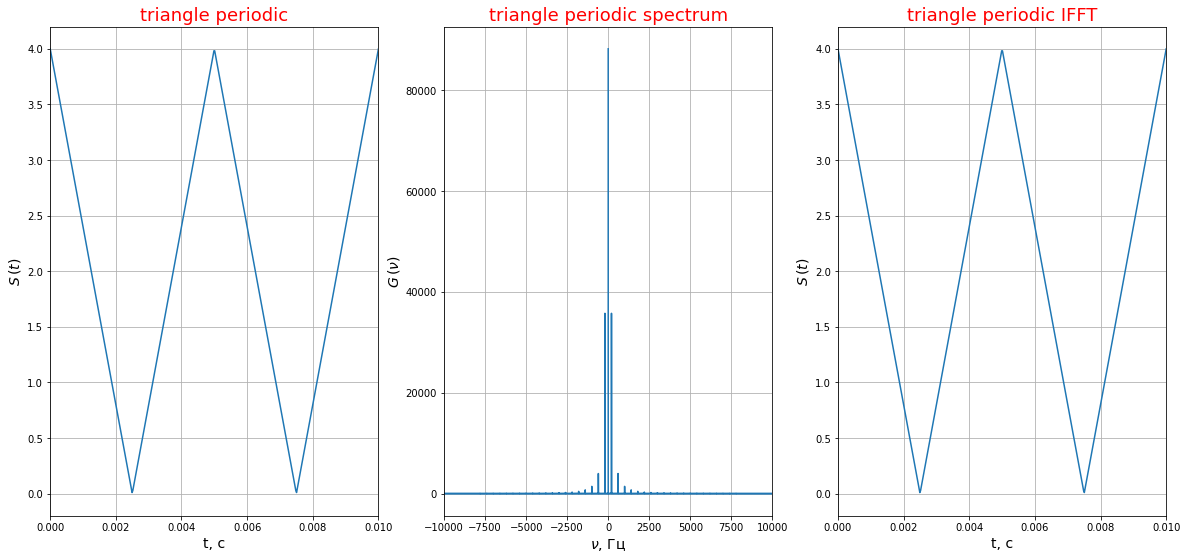

In [ ]:
triangle_periodic      = signal.make_triangle_pulse(freq=200, duration=1000, 
                                                    amp=4, init_phase=0)
triangle_periodic_sp   = spectrum.FFT(triangle_periodic)
triangle_periodic_ifft = spectrum.IFFT(triangle_periodic_sp)

draw(triangle_periodic, triangle_periodic_sp, triangle_periodic_ifft, 
     title1='triangle periodic', title2='triangle periodic spectrum', 
     title3='triangle periodic IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для прямоугольной последовательности импульсов

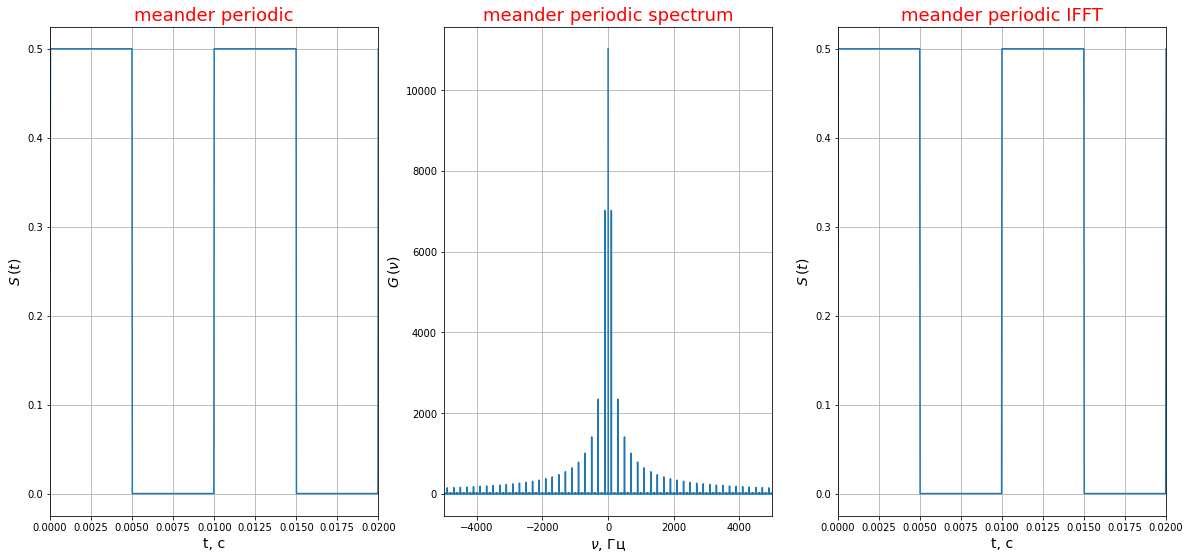

In [ ]:
meander_periodic      = signal.make_meander_pulse(freq=100, duration=1000, 
                                                  amp=0.5, init_phase=0)
meander_periodic_sp   = spectrum.FFT(meander_periodic)
meander_periodic_ifft = spectrum.IFFT(meander_periodic_sp)

draw(meander_periodic, meander_periodic_sp, meander_periodic_ifft, 
     title1='meander periodic', title2='meander periodic spectrum', 
     title3='meander periodic IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для гауссовой последовательности импульсов

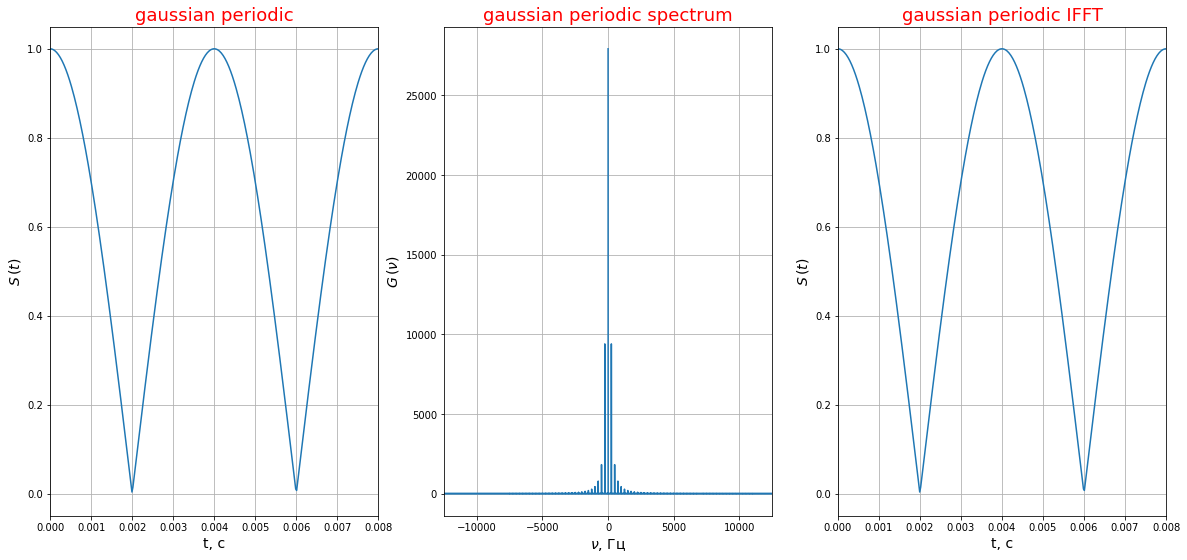

In [ ]:
gaussian_periodic      = signal.make_gaussian_pulse(freq=250, duration=1000, 
                                                    amp=1, init_phase=0)
gaussian_periodic_sp   = spectrum.FFT(gaussian_periodic)
gaussian_periodic_ifft = spectrum.IFFT(gaussian_periodic_sp)

draw(gaussian_periodic, gaussian_periodic_sp, gaussian_periodic_ifft, 
     title1='gaussian periodic', title2='gaussian periodic spectrum', 
     title3='gaussian periodic IFFT')

#### *<span style="color:Green">Последовательность импульсных сигналов с гармоническим заполнением</span>*

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для треугольной последовательности модулированных импульсов

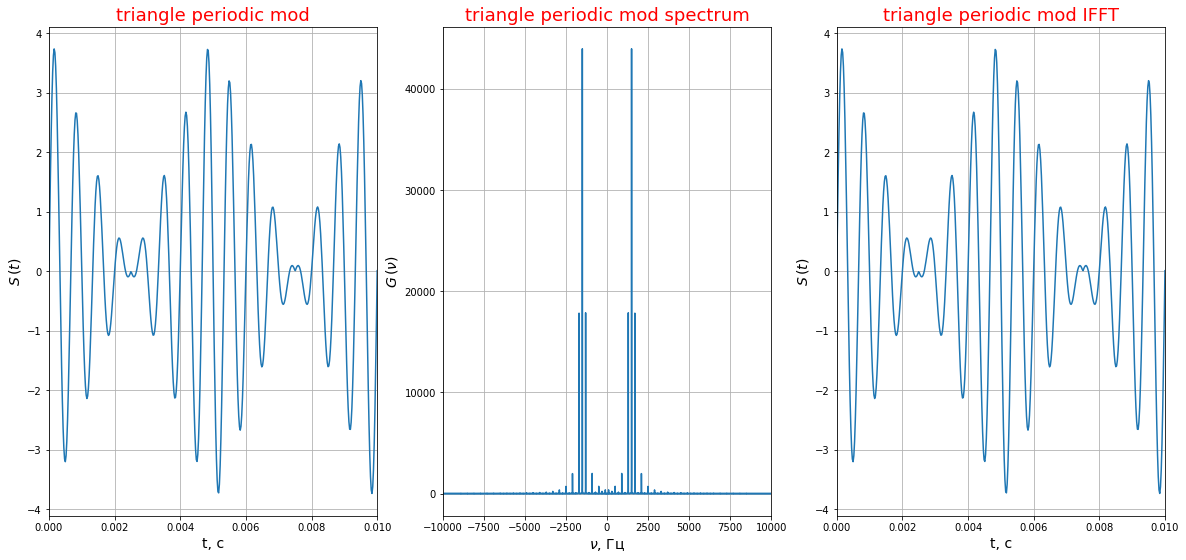

In [ ]:
triangle_periodic_mod      = triangle_periodic.modulate_pulse(mod_freq=1500)
triangle_periodic_mod_sp   = spectrum.FFT(triangle_periodic_mod)
triangle_periodic_mod_ifft = spectrum.IFFT(triangle_periodic_mod_sp)

draw(triangle_periodic_mod, triangle_periodic_mod_sp, triangle_periodic_mod_ifft, 
     title1='triangle periodic mod', title2='triangle periodic mod spectrum', 
     title3='triangle periodic mod IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для прямоугольной последовательности модулированных импульсов

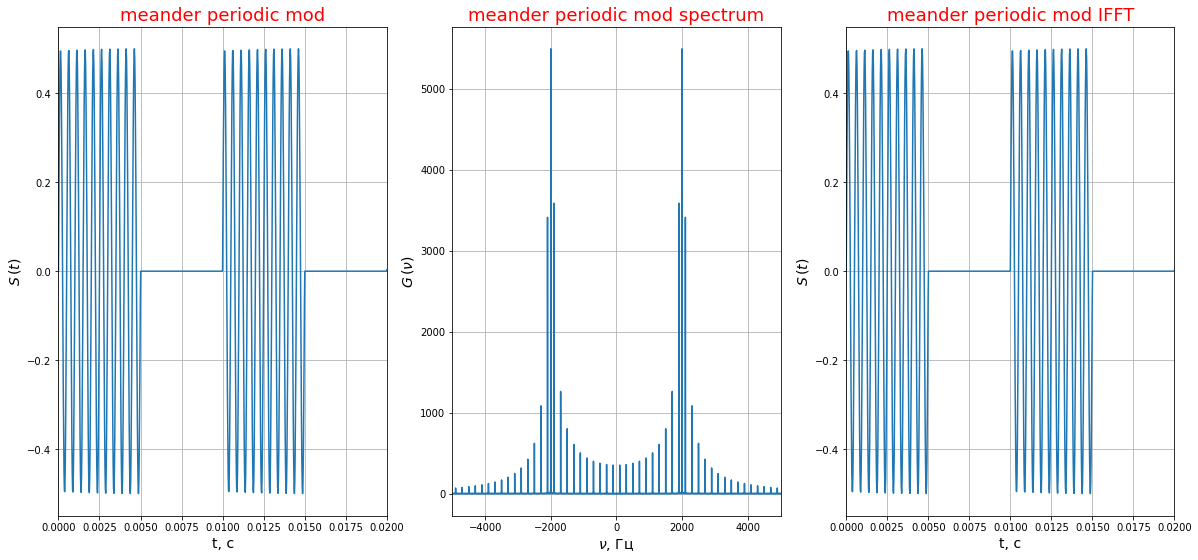

In [ ]:
meander_periodic_mod      = meander_periodic.modulate_pulse(mod_freq=2000)
meander_periodic_mod_sp   = spectrum.FFT(meander_periodic_mod)
meander_periodic_mod_ifft = spectrum.IFFT(meander_periodic_mod_sp)

draw(meander_periodic_mod, meander_periodic_mod_sp, meander_periodic_mod_ifft, 
     title1='meander periodic mod', title2='meander periodic mod spectrum', 
     title3='meander periodic mod IFFT')

##### <span style="color:MediumBlue">Прямое</span> и <span style="color:MediumBlue">обратное БПФ</span> для гауссовой последовательности модулированных импульсов

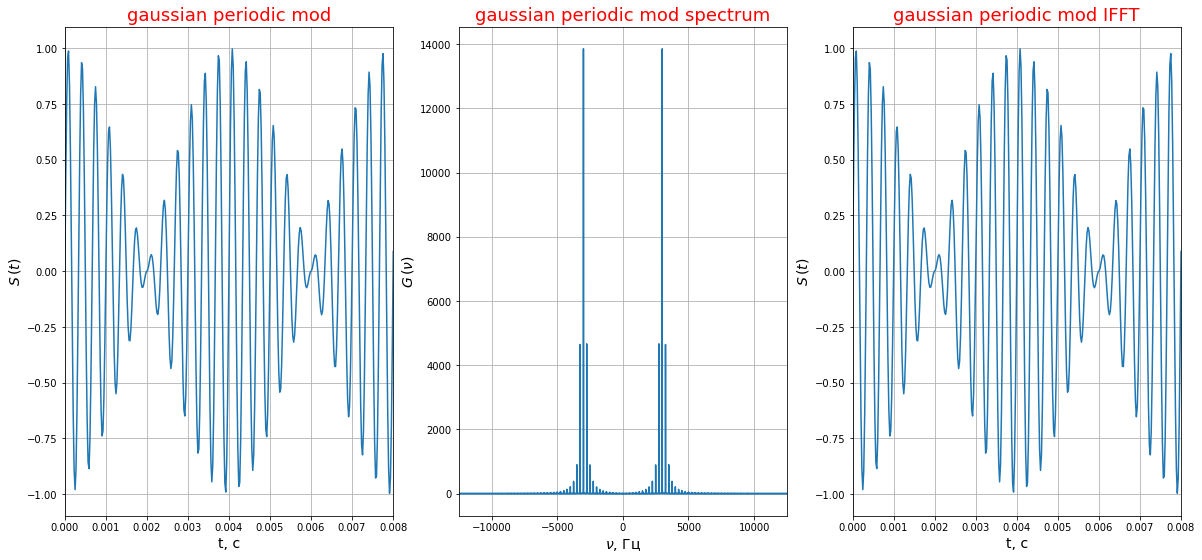

In [ ]:
gaussian_periodic_mod      = gaussian_periodic.modulate_pulse(mod_freq=3000)
gaussian_periodic_mod_sp   = spectrum.FFT(gaussian_periodic_mod)
gaussian_periodic_mod_ifft = spectrum.IFFT(gaussian_periodic_mod_sp)

draw(gaussian_periodic_mod, gaussian_periodic_mod_sp, gaussian_periodic_mod_ifft, 
     title1='gaussian periodic mod', title2='gaussian periodic mod spectrum', 
     title3='gaussian periodic mod IFFT')

----
### *Вывод*

##### В ходе работы нами была рассмотрена задача о применении <span style="color:MediumBlue">Быстрого Преобразования Фурье</span> (<span style="color:MediumBlue">Fast Fourier Transform</span>) для получения спектров сигналов (<span style="color:MediumBlue">прямое БПФ</span>), а также обратная задача получения сигналов из спектров (<span style="color:MediumBlue">обратное БПФ</span>).
##### На конкретных примерах были рассмотрены следующие <span style="color:Gold">виды сигналов</span>:
##### <ul><li>Гармонические сигналы, их суммы с разными частотами (модулированные сигналы);</li> <li>Импульсные сигналы (треугольный, прямоугольный, гауссовый): одиночные импульсы, последовательности импульсов, а также последовательности импульсов с гармоническим заполнением (модуляцией).</li></ul>

##### Также в ходе работы был создан аппарат обработки этих сигналов, который может быть использован в дальнейшем.